In [2]:
import spacy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

The goal of this exercise is to learn to use `spaCy` embedding on a document.

1. Compute the embedding of all the words in this sentence. The language model considered is `en_core_web_md` version 3.4.1.

```
"laptop computer coffee tea water liquid dog cat kitty"
```

In [2]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 19.9 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [3]:
text = "laptop computer coffee tea water liquid dog cat kitty"
nlp = spacy.load("en_core_web_md")
doc = nlp(text)
tokens = [token for token in doc]
labels = [token.text for token in tokens]

for token in tokens:
    print(f"Word: {token.text:10} | Vector Shape: {token.vector.shape}")

print(tokens[0].vector[:20].sum())
print(tokens[1].vector[:20].sum())

Word: laptop     | Vector Shape: (300,)
Word: computer   | Vector Shape: (300,)
Word: coffee     | Vector Shape: (300,)
Word: tea        | Vector Shape: (300,)
Word: water      | Vector Shape: (300,)
Word: liquid     | Vector Shape: (300,)
Word: dog        | Vector Shape: (300,)
Word: cat        | Vector Shape: (300,)
Word: kitty      | Vector Shape: (300,)
5.710388
23.809498


2. Plot the pairwise cosine similarities between all words in a heatmap.

![logo](./w3day05ex1_plot.png)

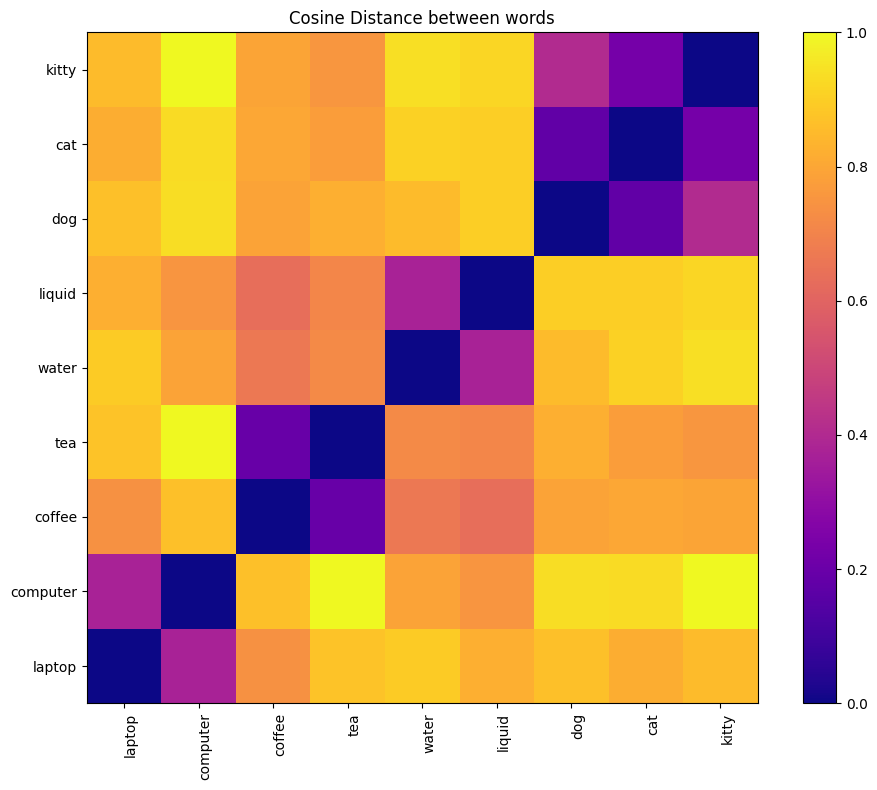

In [4]:
size = len(doc)
matrix = np.zeros((size, size))


for i in range(size):
    for j in range(size):
        similarity = doc[i].similarity(doc[j])
        matrix[i, j] = 1 - similarity

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(matrix, cmap="plasma", origin='lower', vmin=0, vmax=1)

# 4. Configure Axis Labels
ax.set_xticks(np.arange(size))
ax.set_yticks(np.arange(size))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)


plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

plt.colorbar(im)
plt.title("Cosine Distance between words")
plt.tight_layout()

plt.show()